# get tiles from drive


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip -q /content/drive/MyDrive/mmflood_tiled_hydro.zip -d /content/
!ls /content/mmflood_tiled_hydro/

test  train  val


In [4]:
!pip -q install lightning segmentation-models-pytorch==0.3.3 rasterio albumentations torchgeo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 7.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 kB 7.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.7/106.7 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 100.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 605.0/605.0 kB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 74.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 863.6/863.6 kB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [5]:
import os, json, math
from pathlib import Path
from glob import glob
from tqdm.auto import tqdm

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import rasterio
import albumentations as alb
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor
from torchmetrics.classification import BinaryAveragePrecision
from torchgeo.models import ResNet50_Weights

torch.set_float32_matmul_precision('high')
L.seed_everything(1337, workers=True)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

INFO: Seed set to 1337
INFO:lightning.fabric.utilities.seed:Seed set to 1337


Device: cuda


## Config

In [6]:
#Tiles path and ckpt path
TILED_ROOT = Path('/content/mmflood_tiled_hydro')
CKPT_DIR = '/content/drive/MyDrive/mmflood_ckpt_ssl4eo_resnet50_europe_only'
os.makedirs(CKPT_DIR, exist_ok=True)
# Modalities
INCLUDE_DEM = True
USE_HYDRO   = False

MODEL_ARCH      = 'deeplabv3+'
ENCODER_NAME    = 'resnet50'
ENCODER_WEIGHTS = 'ssl4eo'

#paper used 300 epochs, but they had 4 gpus for that so i trianed 100 normally and 50 for the geobias
BATCH_SIZE   = 42
NUM_WORKERS  = 10
MAX_EPOCHS   = 50
LR_START     = 1e-3
LR_END       = 1e-4
POLY_POWER   = 3.0
WEIGHT_DECAY = 0.01
PATIENCE     = 8
EWS_SMOOTHING = 0.8
#default thr but later sweep one is used for maximum iou
REPORT_THR = 0.5

#found in https://github.com/edornd/mmflood/blob/main/floods/datasets/flood.py
_FULL_MEAN = (4.9329374e-02, 1.1776519e-02, 1.4241237e+02)
_FULL_STD  = (3.91287043e-02, 1.03687926e-02, 8.11010422e+01)
N_CH = 2 + int(INCLUDE_DEM) + int(USE_HYDRO)
MEAN = _FULL_MEAN[:N_CH]
STD  = _FULL_STD[:N_CH]

print(f'Config: {MODEL_ARCH}/{ENCODER_NAME}, DEM={INCLUDE_DEM}, epochs={MAX_EPOCHS}, bs={BATCH_SIZE}')
print(f'Channels: {N_CH}, mean={MEAN}, std={STD}')

Config: deeplabv3+/resnet50, DEM=True, epochs=50, bs=42
Channels: 3, mean=(0.049329374, 0.011776519, 142.41237), std=(0.0391287043, 0.0103687926, 81.1010422)


In [7]:
import shutil
import os
TILED_ROOT = Path('/content/mmflood_tiled_hydro')

#europe only train/val vs other in test
with open('/content/drive/MyDrive/activations_europe_only.json') as f:
    act_new = json.load(f)

#dataset activations
with open('/content/drive/MyDrive/activations.json') as f:
    act_old = json.load(f)

MODALITIES = ['sar', 'dem', 'mask', 'hydro']

moved = 0
for emsr_id, info_new in act_new.items():
    info_old = act_old.get(emsr_id, {})
    old_subset = info_old.get('subset')
    new_subset = info_new.get('subset')
    if old_subset == new_subset:
        continue

    #move non europe
    for modality in MODALITIES:
        src_dir = TILED_ROOT / old_subset / modality
        dst_dir = TILED_ROOT / new_subset / modality
        os.makedirs(dst_dir, exist_ok=True)

        #tiles with esmrid
        for tile in src_dir.glob(f'{emsr_id}-*.tif'):
            shutil.move(str(tile), str(dst_dir / tile.name))
            moved += 1
print(moved)

#check
for subset in ['train', 'val', 'test']:
    n = len(list((TILED_ROOT / subset / 'sar').glob('*.tif')))
    print(f'{subset}: {n} Tiles')

2556
train: 2683 Tiles
val: 323 Tiles
test: 895 Tiles


## Tile check

In [9]:
for subset in ['train', 'val', 'test']:
    sar  = len(glob(str(TILED_ROOT / subset / 'sar' / '*.tif')))
    dem  = len(glob(str(TILED_ROOT / subset / 'dem' / '*.tif')))
    mask = len(glob(str(TILED_ROOT / subset / 'mask' / '*.tif')))
    print(f'{subset}: SAR={sar}, DEM={dem}, Mask={mask}')

train: SAR=2683, DEM=2683, Mask=2683
val: SAR=323, DEM=323, Mask=323
test: SAR=895, DEM=895, Mask=895


# Augmentation https://github.com/edornd/mmflood/blob/main/floods/prepare.py

In [10]:
F32_EPS = np.finfo(np.float32).eps

def get_base_transforms(image_size=512):
    min_crop = image_size // 2
    return alb.Compose([
        alb.RandomSizedCrop(min_max_height=(min_crop, image_size),
                            size=(image_size, image_size), p=0.8),
        alb.HorizontalFlip(p=0.5),
        alb.VerticalFlip(p=0.5),
        alb.RandomRotate90(p=0.5),
        alb.ElasticTransform(alpha=1, sigma=50, p=0.5),
        alb.GridDistortion(p=0.5),
    ])

def get_sar_transforms():
    return alb.Compose([
        alb.OneOf([
            alb.GaussianBlur(blur_limit=(3, 13), p=0.5),
            alb.MultiplicativeNoise(multiplier=(0.7, 1.3),
                                    elementwise=True, per_channel=True, p=0.5),
        ], p=0.6),
    ])

class ClipNormalize(alb.ImageOnlyTransform):
    def __init__(self, mean, std, clip_min=-30.0, clip_max=30.0, p=1.0):
        super().__init__(p=p)
        self.mean     = np.array(mean, dtype=np.float32)
        self.std      = np.array(std,  dtype=np.float32)
        self.clip_min = clip_min
        self.clip_max = clip_max

    def apply(self, img, **params):
        img    = img.astype(np.float32)
        mean   = self.mean[:img.shape[-1]]
        std    = self.std[:img.shape[-1]]
        result = (img - mean) / (std + 1e-6)
        return np.clip(result, self.clip_min, self.clip_max)

    def get_transform_init_args_names(self):
        return ('mean', 'std', 'clip_min', 'clip_max')

def get_eval_transforms(mean, std):
    return alb.Compose([
        ClipNormalize(mean=mean, std=std, clip_min=-30.0, clip_max=30.0),
        ToTensorV2(),
    ])

## preprocessed tiles directly used

In [11]:
def imread(path, channels_first=True):
    with rasterio.open(str(path), mode='r', driver='GTiff') as src:
        image = src.read()
    return image if channels_first else image.transpose(1, 2, 0)

def entropy(label: np.ndarray, ignore: int = 255) -> float:
    valid = label.copy()
    valid[valid == ignore] = 0
    marg = np.histogramdd(valid.ravel(), bins=2)[0] / label.size
    marg = list(filter(lambda p: p > 0, np.ravel(marg)))
    return -np.sum(np.multiply(marg, np.log2(marg)))

#basically just rebuilt this from flood.py
class TiledFloodDataset(Dataset):

    def __init__(self, tiled_root, subset, include_dem=True,
                 is_train=False, mean=None, std=None):
        self.include_dem = include_dem
        self.is_train    = is_train

        root = Path(tiled_root) / subset

        self.sar_files  = sorted(glob(str(root / 'sar'  / '*.tif')))
        self.mask_files = sorted(glob(str(root / 'mask' / '*.tif')))
        if include_dem:
            self.dem_files = sorted(glob(str(root / 'dem' / '*.tif')))
        else:
            self.dem_files = []

        assert len(self.sar_files) > 0, f'Keine Tiles in {root}/sar'
        assert len(self.sar_files) == len(self.mask_files), 'SAR/Mask Mismatch'
        if include_dem:
            assert len(self.sar_files) == len(self.dem_files), 'SAR/DEM Mismatch'


        self.base_trf = get_base_transforms(512) if is_train else None
        self.sar_trf  = get_sar_transforms()     if is_train else None
        self.norm_trf = get_eval_transforms(mean=mean, std=std)

        self.label_files = self.mask_files

        print(subset)
        print(self.sar_files)

    def __len__(self):
        return len(self.sar_files)

    def __getitem__(self, idx):
        #load sar
        sar = imread(self.sar_files[idx]).astype(np.float32)  #(2,H,W)
        sar = np.nan_to_num(sar, nan=0.0)

        #masks
        mask = imread(self.mask_files[idx])[0].astype(np.uint8)  #(H,W)
        y01  = mask.astype(np.int64)
        y01[(y01 != 0) & (y01 != 255)] = 1

        #augmentation on sar channels only
        sar_hwc = sar.transpose(1, 2, 0)
        if self.sar_trf is not None:
            result  = self.sar_trf(image=sar_hwc, mask=y01.astype(np.float32))
            sar_hwc = result['image']
            y01     = result['mask'].astype(np.int64)

        #stack dem
        if self.include_dem:
            dem = imread(self.dem_files[idx]).astype(np.float32)[0]  # (H, W)
            dem = np.nan_to_num(dem, nan=0.0)
            full_hwc = np.dstack((sar_hwc, dem[:, :, np.newaxis]))  # (H, W, 3)
        else:
            full_hwc = sar_hwc

        #full augmenation
        if self.base_trf is not None:
            result   = self.base_trf(image=full_hwc, mask=y01.astype(np.float32))
            full_hwc = result['image']
            y01      = result['mask'].astype(np.int64)

        #normalize
        result = self.norm_trf(image=full_hwc.astype(np.float32),
                               mask=y01.astype(np.float32))
        x_t = result['image'].float()
        #safety incase albumentation created nans
        x_t = torch.nan_to_num(x_t, nan=0.0)
        y_t = result['mask'].long()

        name = Path(self.sar_files[idx]).stem
        return x_t, y_t, name.split('_')[0], name

## DataModule mit EWS

In [12]:
def compute_entropy_weights(label_files, smoothing=0.8):
    assert 0 <= smoothing <= 1
    minval = 1.0 - smoothing
    entropies = []
    for path in tqdm(label_files, desc='EWS'):
        label = imread(path)[0]
        entropies.append(entropy(label))
    entropies = np.array(entropies)
    return np.clip(entropies * smoothing + minval, 0, 1)


def mmflood_collate(batch):
    xs, ys, ids, names = zip(*batch)
    return (
        torch.stack([x.clone().contiguous() for x in xs]),
        torch.stack([y.clone().contiguous() for y in ys]),
        list(ids), list(names),
    )


class MMFloodDataModule(L.LightningDataModule):

    def __init__(self, tiled_root, batch_size=42, num_workers=10,
                 include_dem=True, ews_smoothing=0.8, mean=None, std=None):
        super().__init__()
        self.tiled_root   = tiled_root
        self.batch_size   = batch_size
        self.num_workers  = num_workers
        self.include_dem  = include_dem
        self.ews_smoothing= ews_smoothing
        self.mean         = mean
        self.std          = std

    def setup(self, stage=None):
        kw = dict(include_dem=self.include_dem, mean=self.mean, std=self.std)
        self.train_ds = TiledFloodDataset(self.tiled_root, 'train',
                                          is_train=True, **kw)
        self.val_ds   = TiledFloodDataset(self.tiled_root, 'val',
                                          is_train=False, **kw)
        self.test_ds  = TiledFloodDataset(self.tiled_root, 'test',
                                          is_train=False, **kw)


        weights     = compute_entropy_weights(self.train_ds.label_files,
                                              smoothing=self.ews_smoothing)
        num_samples = len(self.train_ds) * 2
        self._sampler = WeightedRandomSampler(
            weights=torch.from_numpy(weights).double(),
            num_samples=num_samples,
            replacement=True,
        )
        print(f'Train: {len(self.train_ds)} | Val: {len(self.val_ds)} | Test: {len(self.test_ds)}')

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.batch_size,sampler=self._sampler, num_workers=self.num_workers,pin_memory=True, collate_fn=mmflood_collate, drop_last=True)

    def val_dataloader(self):
        return DataLoader(self.val_ds, batch_size=self.batch_size, shuffle=False, num_workers=self.num_workers, pin_memory=True,collate_fn=mmflood_collate)

    def test_dataloader(self):
        return DataLoader(self.test_ds, batch_size=1, shuffle=False, num_workers=self.num_workers, pin_memory=True, collate_fn=mmflood_collate)

## Loss: Weighted BCE

In [13]:
def weighted_bce_loss(logits, y, ignore=255):
  #igars2025 paper
    valid = (y != ignore)
    if valid.sum() == 0:
        return logits.sum() * 0.0
    y_valid    = y[valid]
    n_neg      = (y_valid == 0).sum().float()
    n_pos      = (y_valid == 1).sum().float()
    pos_weight = torch.clamp(n_neg / (n_pos + 1), min=1.0, max=50.0)
    return F.binary_cross_entropy_with_logits(
        logits[valid],
        (y_valid == 1).float(),
        pos_weight=pos_weight.to(logits.device),
    )


def micro_stats(logits, y, thr=0.5, ignore=255):
    pred  = torch.sigmoid(logits) > thr
    valid = (y != ignore)
    y01   = (y == 1)
    tp = ( pred &  y01 & valid).sum()
    fp = ( pred & ~y01 & valid).sum()
    fn = (~pred &  y01 & valid).sum()
    return tp, fp, fn


## LightningModule

In [14]:
class FloodTask(L.LightningModule):

    def __init__(self, in_channels=3, lr_start=1e-3, lr_end=1e-4,
                 poly_power=3.0, weight_decay=0.01, report_thr=0.5,
                 max_epochs=200, model_arch='deeplabv3+',
                 encoder_name='resnet50', encoder_weights=None):
        super().__init__()
        self.save_hyperparameters()

        self.val_ap  = BinaryAveragePrecision()
        self.test_ap = BinaryAveragePrecision()
        self._reset_accum('val')
        self._reset_accum('test')

        arch = str(model_arch).lower()
        weights = ResNet50_Weights.SENTINEL1_ALL_MOCO
        kw = dict(encoder_name=encoder_name,
                  encoder_weights=None,
                  in_channels=in_channels, classes=1)

        if arch in ['deeplabv3+', 'deeplabv3plus']:
            self.model = smp.DeepLabV3Plus(**kw)
        elif arch in ['unet', 'u-net']:
            self.model = smp.Unet(**kw)

        if encoder_weights == 'ssl4eo':
            w = ResNet50_Weights.SENTINEL1_ALL_MOCO
            ssl4eo_state = w.get_state_dict(progress=True)

            #ssl doesnt have dem weights so we need to take them from trained model
            trained_ckpt = torch.load('/content/drive/MyDrive/mmflood_checkpoints_final/best-epoch=101-iouval/iou=0.2974.ckpt',
                                      map_location='cpu')
            trained_conv1 = trained_ckpt['state_dict']['model.encoder.conv1.weight']

            new_conv1 = trained_conv1.clone()
            new_conv1[:, :2, :, :] = ssl4eo_state['conv1.weight']
            new_conv1[:, 2:, :, :] = trained_conv1[:, 2:, :, :]
            ssl4eo_state['conv1.weight'] = new_conv1

            self.model.encoder.load_state_dict(ssl4eo_state, strict=False)
            print("SSL4EO + trained DEM")

    def _reset_accum(self, stage):
        for k in ['tp', 'fp', 'fn', 'valid_total']:
            setattr(self, f'_{stage}_{k}', torch.tensor(0, dtype=torch.long))
    def forward(self, x):
        return self.model(x).squeeze(1)

    def configure_optimizers(self):
        opt = torch.optim.AdamW(
            self.parameters(),
            lr=self.hparams.lr_start,
            weight_decay=self.hparams.weight_decay
        )
        def poly_lr(epoch):
            T    = self.hparams.max_epochs
            g    = self.hparams.poly_power
            lr_s = self.hparams.lr_start
            lr_e = self.hparams.lr_end
            return (lr_e + (lr_s - lr_e) * (1 - epoch / T) ** g) / lr_s
        sched = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda=poly_lr)
        return [opt], [{'scheduler': sched, 'interval': 'epoch'}]

    def training_step(self, batch, _):
        self.model.train()
        x, y, *_ = batch
        logits    = self(x)
        loss      = weighted_bce_loss(logits, y)
        if not torch.isfinite(loss):
            return logits.sum() * 0.0
        self.log('train/loss', loss, prog_bar=True, on_epoch=True,
                 on_step=False, batch_size=x.shape[0])
        return loss

    def _eval_step(self, batch, stage):
        x, y, *_ = batch
        logits    = self(x)
        loss      = weighted_bce_loss(logits, y)
        if not torch.isfinite(loss):
            return
        self.log(f'{stage}/loss', loss, prog_bar=True, on_epoch=True,
                 on_step=False, batch_size=x.shape[0])

        tp, fp, fn = micro_stats(logits, y, thr=self.hparams.report_thr)
        getattr(self, f'_{stage}_tp').add_(tp.cpu())
        getattr(self, f'_{stage}_fp').add_(fp.cpu())
        getattr(self, f'_{stage}_fn').add_(fn.cpu())

        valid = (y != 255)
        getattr(self, f'_{stage}_valid_total').add_(valid.sum().cpu())
        y01   = (y == 1)
        with torch.no_grad():
            p_flat = torch.sigmoid(logits[valid]).detach().float()
            y_flat = y01[valid].detach().int()
            getattr(self, f'{stage}_ap').update(p_flat, y_flat)

        with torch.no_grad():
            probs = torch.sigmoid(logits)
            vm    = valid.float()
            p_    = probs * vm
            t_    = y01.float() * vm
            inter = (p_ * t_).sum(dim=(1, 2))
            denom = p_.sum(dim=(1, 2)) + t_.sum(dim=(1, 2)) + 1e-6
            dice_soft = ((2 * inter + 1e-6) / denom).mean()
        self.log(f'{stage}/dice_soft', dice_soft, prog_bar=True,
                 on_epoch=True, on_step=False, batch_size=x.shape[0])

    def validation_step(self, batch, _): self._eval_step(batch, 'val')
    def test_step(self, batch, _):
        x, y, *_ = batch
        B, C, H, W = x.shape
        pad_h = (16 - H % 16) % 16
        pad_w = (16 - W % 16) % 16
        if pad_h > 0 or pad_w > 0:
            x = F.pad(x, (0, pad_w, 0, pad_h), value=0)
            y = F.pad(y, (0, pad_w, 0, pad_h), value=255)
        self._eval_step((x, y), 'test')

    def _log_epoch_metrics(self, stage):
        tp   = getattr(self, f'_{stage}_tp').float()
        fp   = getattr(self, f'_{stage}_fp').float()
        fn   = getattr(self, f'_{stage}_fn').float()
        iou  = tp / (tp + fp + fn + F32_EPS)
        prec = tp / (tp + fp + F32_EPS)
        rec  = tp / (tp + fn + F32_EPS)
        f1   = 2 * prec * rec / (prec + rec + F32_EPS)
        try:
            ap = getattr(self, f'{stage}_ap').compute()
        except Exception:
            ap = torch.tensor(0.0)
        iou_flood = tp / (tp + fp + fn + F32_EPS)
        valid_total = getattr(self, f'_{stage}_valid_total').float()
        tn = valid_total - tp - fp - fn
        iou_bg = tn / (tn + fn + fp + F32_EPS)


        miou = (iou_flood + iou_bg) / 2
        self.log(f'{stage}/iou',  iou,  prog_bar=True)
        self.log(f'{stage}/prec', prec)
        self.log(f'{stage}/rec',  rec)
        self.log(f'{stage}/f1',   f1)
        self.log(f'{stage}/AP',   ap)
        self.log(f'{stage}/miou', miou)
        print(f'[{stage.upper()}] IoU={iou:.4f}  Prec={prec:.4f}  '
              f'Rec={rec:.4f}  F1={f1:.4f}  AP={ap:.4f}')

        self._reset_accum(stage)
        getattr(self, f'{stage}_ap').reset()

    def on_validation_epoch_end(self): self._log_epoch_metrics('val')
    def on_test_epoch_end(self):       self._log_epoch_metrics('test')

## Setup

In [15]:
dm = MMFloodDataModule(
    tiled_root=TILED_ROOT,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    include_dem=INCLUDE_DEM,
    ews_smoothing=EWS_SMOOTHING,
    mean=MEAN,
    std=STD,
)
dm.setup()

train
['/content/mmflood_tiled_hydro/train/sar/EMSR107-5-12_0_0.tif', '/content/mmflood_tiled_hydro/train/sar/EMSR107-5-12_0_509.tif', '/content/mmflood_tiled_hydro/train/sar/EMSR107-5-12_338_0.tif', '/content/mmflood_tiled_hydro/train/sar/EMSR107-5-12_338_509.tif', '/content/mmflood_tiled_hydro/train/sar/EMSR107-5-13_0_0.tif', '/content/mmflood_tiled_hydro/train/sar/EMSR107-5-13_0_423.tif', '/content/mmflood_tiled_hydro/train/sar/EMSR107-5-13_0_846.tif', '/content/mmflood_tiled_hydro/train/sar/EMSR107-5-13_332_0.tif', '/content/mmflood_tiled_hydro/train/sar/EMSR107-5-13_332_423.tif', '/content/mmflood_tiled_hydro/train/sar/EMSR107-5-13_332_846.tif', '/content/mmflood_tiled_hydro/train/sar/EMSR107-5-13_663_0.tif', '/content/mmflood_tiled_hydro/train/sar/EMSR107-5-13_663_423.tif', '/content/mmflood_tiled_hydro/train/sar/EMSR107-5-13_663_846.tif', '/content/mmflood_tiled_hydro/train/sar/EMSR107-5-15_0_0.tif', '/content/mmflood_tiled_hydro/train/sar/EMSR107-5-15_0_165.tif', '/content/mmfl

EWS:   0%|          | 0/2683 [00:00<?, ?it/s]

Train: 2683 | Val: 323 | Test: 895


## Training


In [16]:
model = FloodTask(
    in_channels=N_CH,
    lr_start=LR_START, lr_end=LR_END,
    poly_power=POLY_POWER, weight_decay=WEIGHT_DECAY,
    report_thr=REPORT_THR, max_epochs=MAX_EPOCHS,
    model_arch=MODEL_ARCH, encoder_name=ENCODER_NAME,
    encoder_weights=ENCODER_WEIGHTS,
)

callbacks = [
    ModelCheckpoint(
        dirpath=CKPT_DIR,
        monitor='val/iou', mode='max', save_top_k=1,
        filename='best-{epoch:03d}-iou{val/iou:.4f}',
        verbose=True,
    ),
    EarlyStopping(
        monitor='val/iou', mode='max',
        patience=PATIENCE, verbose=True,
    ),
    LearningRateMonitor(logging_interval='epoch'),
]

trainer = L.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator='gpu' if device == 'cuda' else 'cpu',
    devices=1,
    precision='16-mixed',
    callbacks=callbacks,
    log_every_n_steps=20,
    gradient_clip_val=1.0,
    gradient_clip_algorithm='norm',
    check_val_every_n_epoch=2,
    enable_progress_bar=True,
)

trainer.fit(model, dm, ckpt_path="/content/drive/MyDrive/mmflood_ckpt_ssl4eo_resnet50_europe_only/best-epoch=015-iouval/iou=0.2781.ckpt")

Downloading: "https://hf.co/torchgeo/resnet50_sentinel1_all_moco/resolve/e79862c667853c10a709bdd77ea8ffbad0e0f1cf/resnet50_sentinel1_all_moco-906e4356.pth" to /root/.cache/torch/hub/checkpoints/resnet50_sentinel1_all_moco-906e4356.pth


100%|██████████| 90.0M/90.0M [00:00<00:00, 376MB/s]
INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


SSL4EO + trained DEM
train
['/content/mmflood_tiled_hydro/train/sar/EMSR107-5-12_0_0.tif', '/content/mmflood_tiled_hydro/train/sar/EMSR107-5-12_0_509.tif', '/content/mmflood_tiled_hydro/train/sar/EMSR107-5-12_338_0.tif', '/content/mmflood_tiled_hydro/train/sar/EMSR107-5-12_338_509.tif', '/content/mmflood_tiled_hydro/train/sar/EMSR107-5-13_0_0.tif', '/content/mmflood_tiled_hydro/train/sar/EMSR107-5-13_0_423.tif', '/content/mmflood_tiled_hydro/train/sar/EMSR107-5-13_0_846.tif', '/content/mmflood_tiled_hydro/train/sar/EMSR107-5-13_332_0.tif', '/content/mmflood_tiled_hydro/train/sar/EMSR107-5-13_332_423.tif', '/content/mmflood_tiled_hydro/train/sar/EMSR107-5-13_332_846.tif', '/content/mmflood_tiled_hydro/train/sar/EMSR107-5-13_663_0.tif', '/content/mmflood_tiled_hydro/train/sar/EMSR107-5-13_663_423.tif', '/content/mmflood_tiled_hydro/train/sar/EMSR107-5-13_663_846.tif', '/content/mmflood_tiled_hydro/train/sar/EMSR107-5-15_0_0.tif', '/content/mmflood_tiled_hydro/train/sar/EMSR107-5-15_0_165

EWS:   0%|          | 0/2683 [00:00<?, ?it/s]

Train: 2683 | Val: 323 | Test: 895


...

Output()

INFO: 
Detected KeyboardInterrupt, attempting graceful shutdown ...
INFO:lightning.pytorch.utilities.rank_zero:
Detected KeyboardInterrupt, attempting graceful shutdown ...


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/call.py", line 49, in _call_and_handle_interrupt
    return trainer_fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/trainer.py", line 630, in _fit_impl
    self._run(model, ckpt_path=ckpt_path, weights_only=weights_only)
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/trainer.py", line 1079, in _run
    results = self._run_stage()
              ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/trainer.py", line 1123, in _run_stage
    self.fit_loop.run()
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/fit_loop.py", line 217, in run
    self.advance()
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/fit_loop.py", line 465, in advance
    self.epoch_loop.run(self._data_fetcher)
  File

TypeError: object of type 'NoneType' has no len()


eval

In [17]:
best_ckpt = "/content/drive/MyDrive/mmflood_ckpt_ssl4eo_resnet50_europe_only/best-epoch=049-iouval/iou=0.3030.ckpt"

#new test loader
from torch.utils.data import DataLoader
test_loader = DataLoader(
    dm.test_ds,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    collate_fn=mmflood_collate
)

#new trainer
trainer2 = L.Trainer(
    accelerator='gpu' if device == 'cuda' else 'cpu',
    devices=1,
    precision='16-mixed',
    enable_progress_bar=True,
)
#test model with best checkpoint and sweeped threshold
best_model = FloodTask.load_from_checkpoint(best_ckpt,report_thr=0.75)
best_model.to(device)
trainer2.test(best_model, dataloaders=test_loader)

INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


KeyboardInterrupt: 

hier aber die iou als (iouwater +iouland) /2 dann bin ich glaub ich schon relativ nah

## Threshold check
bce loss doesnt maximize iou so changing thr can increase iou further

---



In [18]:
best_ckpt ="/content/drive/MyDrive/mmflood_ckpt_ssl4eo_resnet50_europe_only/best-epoch=049-iouval/iou=0.3030.ckpt"
@torch.no_grad()
def cache_probs(model, loader, device):
    model.eval()
    probs_all, y_all = [], []
    for x, y, *_ in loader:
        logits = model(x.to(device))
        probs  = torch.sigmoid(logits).cpu()
        valid  = (y != 255)
        probs_all.append(probs[valid])
        y_all.append((y == 1)[valid])
    return torch.cat(probs_all), torch.cat(y_all).bool()

best_model = FloodTask.load_from_checkpoint(best_ckpt)
best_model.to(device).eval()

probs, y_val = cache_probs(best_model, dm.val_dataloader(), device)

print(f'\n{"Thr":>5}  {"IoU":>7}  {"F1":>7}  {"Prec":>7}  {"Rec":>7}')
best_thr, best_iou = 0.5, 0.0
for thr in np.arange(0.05, 0.95, 0.05):
    pb   = probs > thr
    tp   = ( pb &  y_val).sum().item()
    fp   = ( pb & ~y_val).sum().item()
    fn   = (~pb &  y_val).sum().item()
    iou  = tp / (tp + fp + fn + 1e-9)
    prec = tp / (tp + fp + 1e-9)
    rec  = tp / (tp + fn + 1e-9)
    f1   = 2 * prec * rec / (prec + rec + 1e-9)
    mark = 'x' if iou > best_iou else ''
    print(f'{thr:5.2f}  {iou:7.4f}  {f1:7.4f}  {prec:7.4f}  {rec:7.4f}')
    if iou > best_iou:
        best_iou, best_thr = iou, float(thr)

print(f'\n Bester thr: {best_thr:.2f}  (IoU={best_iou:.4f})')

SSL4EO + trained DEM

  Thr      IoU       F1     Prec      Rec
 0.05   0.1405   0.2464   0.1419   0.9342
 0.10   0.1732   0.2953   0.1762   0.9124
 0.15   0.1965   0.3284   0.2011   0.8959
 0.20   0.2156   0.3547   0.2221   0.8803
 0.25   0.2326   0.3775   0.2414   0.8651
 0.30   0.2485   0.3981   0.2599   0.8498
 0.35   0.2635   0.4171   0.2781   0.8340
 0.40   0.2775   0.4345   0.2960   0.8168
 0.45   0.2907   0.4504   0.3138   0.7976
 0.50   0.3029   0.4650   0.3320   0.7758
 0.55   0.3146   0.4787   0.3512   0.7515
 0.60   0.3257   0.4913   0.3718   0.7241
 0.65   0.3355   0.5025   0.3940   0.6933
 0.70   0.3441   0.5121   0.4190   0.6584
 0.75   0.3498   0.5183   0.4474   0.6159
 0.80   0.3497   0.5182   0.4803   0.5625
 0.85   0.3344   0.5012   0.5168   0.4866
 0.90   0.2893   0.4488   0.5562   0.3761

 Bester thr: 0.75  (IoU=0.3498)


In [19]:
best_ckpt="/content/drive/MyDrive/mmflood_ckpt_ssl4eo_resnet50_europe_only/best-epoch=049-iouval/iou=0.3030.ckpt"
best_model = FloodTask.load_from_checkpoint(best_ckpt)
best_model.to(device).eval()

SSL4EO + trained DEM


FloodTask(
  (val_ap): BinaryAveragePrecision()
  (test_ap): BinaryAveragePrecision()
  (model): DeepLabV3Plus(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-

In [20]:
import json
from pathlib import Path
from glob import glob
from collections import Counter, defaultdict
import torch
from torch.utils.data import DataLoader, Subset
import torch.nn.functional as F
from torchmetrics.classification import BinaryAveragePrecision

ACTIVATIONS = '/content/drive/MyDrive/activations.json'

COUNTRY_TO_CONTINENT = {
    'Germany': 'Europe', 'France': 'Europe', 'Italy': 'Europe', 'Spain': 'Europe',
    'Austria': 'Europe', 'Belgium': 'Europe', 'Netherlands': 'Europe', 'Greece': 'Europe',
    'Slovakia': 'Europe', 'Sweden': 'Europe', 'Lithuania': 'Europe', 'Romania': 'Europe',
    'Norway': 'Europe', 'Slovenia': 'Europe', 'Portugal': 'Europe', 'Croatia': 'Europe',
    'Finland': 'Europe', 'Albania': 'Europe', 'Ireland': 'Europe', 'United Kingdom': 'Europe',
    'Ukraine': 'Europe', 'Latvia': 'Europe', 'Moldova': 'Europe',
    'Bosnia and Herzegovina': 'Europe', 'Bosnia and Herze...': 'Europe',
    'India': 'Asia', 'China': 'Asia', 'Bangladesh': 'Asia', 'Pakistan': 'Asia',
    'Indonesia': 'Asia', 'Vietnam': 'Asia', 'Timor-Leste': 'Asia', 'Tajikistan': 'Asia',
    'Nigeria': 'Africa', 'Mozambique': 'Africa', 'Sudan': 'Africa', 'Uganda': 'Africa',
    'Madagascar': 'Africa', 'Djibouti': 'Africa', 'Togo': 'Africa',
    'United States': 'North America', 'USA': 'North America', 'Canada': 'North America',
    'Mexico': 'North America', 'Honduras': 'North America', 'Nicaragua': 'North America',
    'Brazil': 'South America', 'Argentina': 'South America', 'Colombia': 'South America',
    'Peru': 'South America', 'Guyana': 'South America',
    'Australia': 'Oceania',
}

def country_to_continent(country_string):
    if not country_string:
        return 'Unknown'
    parts = [p.strip() for p in country_string.split(',')]
    continents = {COUNTRY_TO_CONTINENT.get(p) for p in parts}
    continents.discard(None)
    if len(continents) == 1:
        return continents.pop()
    if len(continents) > 1:
        return 'Multi-Continent'
    return 'Unknown'

with open(ACTIVATIONS) as f:
    activations = json.load(f)

EMSR_TO_CONTINENT = {
    k: country_to_continent(v.get('country', ''))
    for k, v in activations.items()
}

def tile_to_continent(tile_path):
    emsr_id = Path(tile_path).stem.split('-')[0]
    return EMSR_TO_CONTINENT.get(emsr_id, 'Unknown')

test_sar_files = sorted(glob(str(TILED_ROOT / 'test' / 'sar' / '*.tif')))
tile_continents = [tile_to_continent(f) for f in test_sar_files]
print('Test-Tiles pro Kontinent:', dict(Counter(tile_continents)))

#group per cont
continent_indices = defaultdict(list)
for idx, continent in enumerate(tile_continents):
    continent_indices[continent].append(idx)

geo_results = {}

for continent, indices in sorted(continent_indices.items()):
    if len(indices) < 1:
        print(f' skip {continent} ({len(indices)} Tiles)')
        continue

    subset_ds = Subset(dm.test_ds, indices)
    subset_loader = DataLoader(
        subset_ds,
        batch_size=1,
        shuffle=False,
        num_workers=0,
        collate_fn=mmflood_collate,
    )

    best_model.eval()
    tp = fp = fn = 0
    ap_metric = BinaryAveragePrecision().to(device)
    with torch.no_grad():
        for x, y, *_ in subset_loader:
            B, C, H, W = x.shape
            pad_h = (16 - H % 16) % 16
            pad_w = (16 - W % 16) % 16
            if pad_h > 0 or pad_w > 0:
                x = F.pad(x, (0, pad_w, 0, pad_h), mode='reflect')
                y = F.pad(y, (0, pad_w, 0, pad_h), value=255)

            logits = best_model(x.to(device))

            valid = (y != 255)
            if valid.sum() > 0:
                ap_metric.update(torch.sigmoid(logits[valid]).detach().float(), (y[valid] == 1).detach().int())

            pred = (torch.sigmoid(logits) > 0.75).long().cpu()
            p = pred[valid]
            g = (y == 1)[valid].long()
            tp += (p * g).sum().item()
            fp += (p * (1 - g)).sum().item()
            fn += ((1 - p) * g).sum().item()

    iou = tp / (tp + fp + fn + 1e-8)
    prec = tp / (tp + fp + 1e-8)
    rec = tp / (tp + fn + 1e-8)
    f1 = 2 * prec * rec / (prec + rec + 1e-8)
    try:
        ap = ap_metric.compute().item()
    except:
        ap = float('nan')
    geo_results[continent] = {'iou': iou, 'f1': f1, 'precision': prec, 'recall': rec, 'ap': ap, 'n_tiles': len(indices), 'tp': tp, 'fp': fp, 'fn': fn}
    print(f'  {continent:20s}  IoU={iou:.4f}  F1={f1:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  AP={ap:.4f}  (n={len(indices)})')

print(f'{"Kontinent":<20}  {"IoU":>7}  {"F1":>7}  {"Prec":>7}  {"Rec":>7}  {"AP":>7}  {"n":>5}')
for k, v in sorted(geo_results.items(), key=lambda x: -x[1]['iou']):
    print(f'  {k:<20}  {v["iou"]:7.4f}  {v["f1"]:7.4f}  {v["precision"]:7.4f}  {v["recall"]:7.4f}  {v["ap"]:7.4f}  {v["n_tiles"]:5d}')



Test-Tiles pro Kontinent: {'Europe': 210, 'Asia': 36, 'Oceania': 76, 'South America': 25, 'North America': 237, 'Africa': 311}
  Africa                IoU=0.4174  F1=0.5889  Prec=0.5335  Rec=0.6572  AP=nan  (n=311)
  Asia                  IoU=0.2393  F1=0.3862  Prec=0.3664  Rec=0.4081  AP=nan  (n=36)
  Europe                IoU=0.3180  F1=0.4825  Prec=0.4098  Rec=0.5867  AP=nan  (n=210)
  North America         IoU=0.1857  F1=0.3132  Prec=0.2244  Rec=0.5181  AP=nan  (n=237)
  Oceania               IoU=0.2879  F1=0.4471  Prec=0.4435  Rec=0.4508  AP=nan  (n=76)
  South America         IoU=0.1965  F1=0.3284  Prec=0.2038  Rec=0.8459  AP=nan  (n=25)
Kontinent                 IoU       F1     Prec      Rec       AP      n
  Africa                 0.4174   0.5889   0.5335   0.6572      nan    311
  Europe                 0.3180   0.4825   0.4098   0.5867      nan    210
  Oceania                0.2879   0.4471   0.4435   0.4508      nan     76
  Asia                   0.2393   0.3862   0.3664 

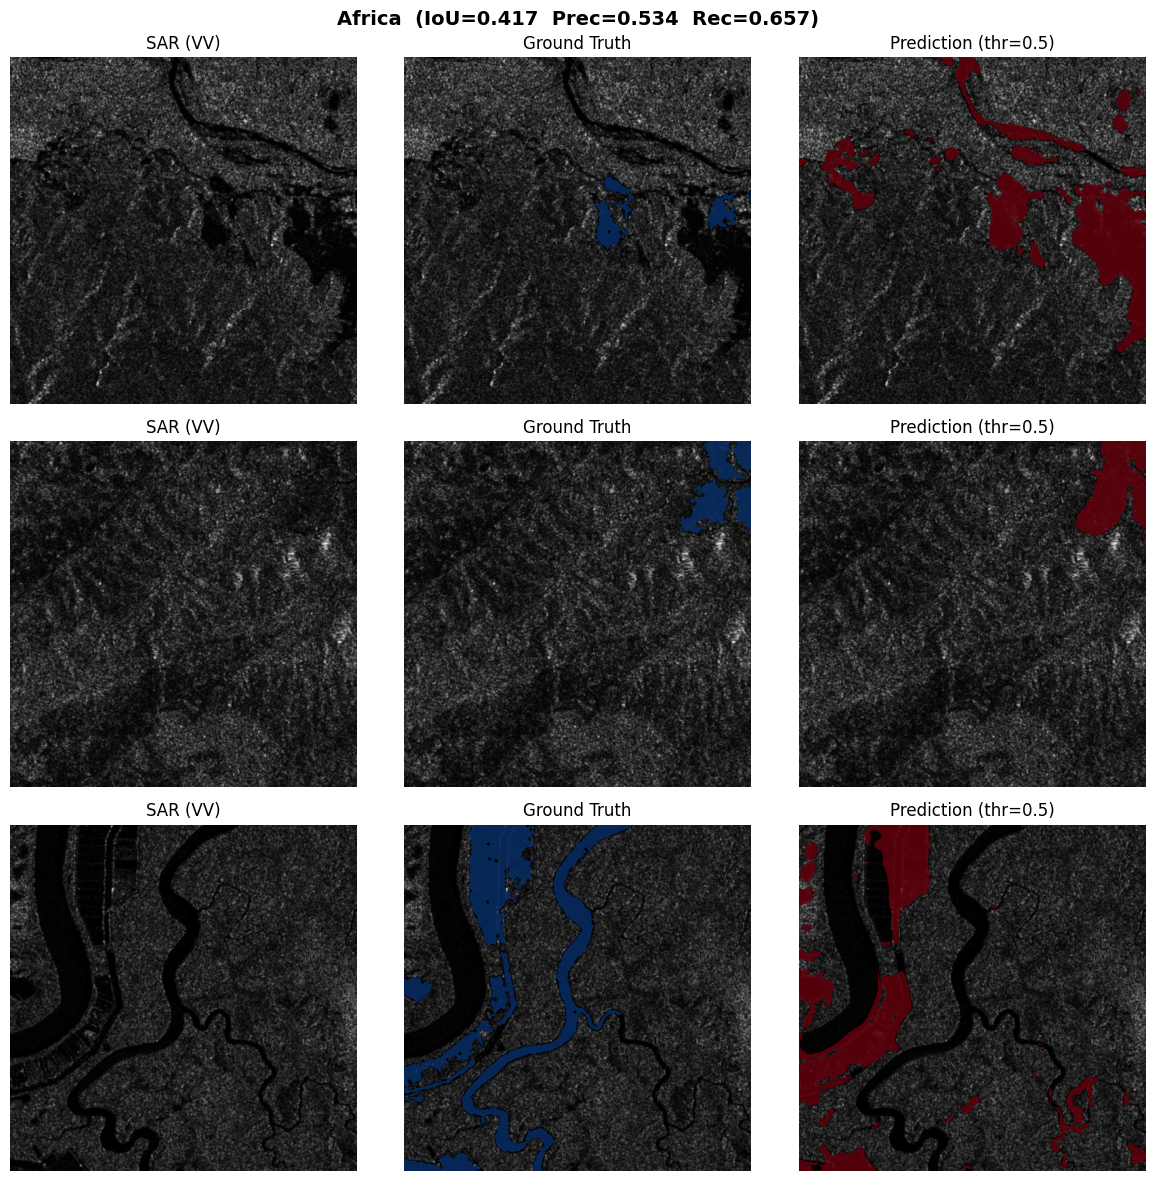

geo_vis_Africa.png


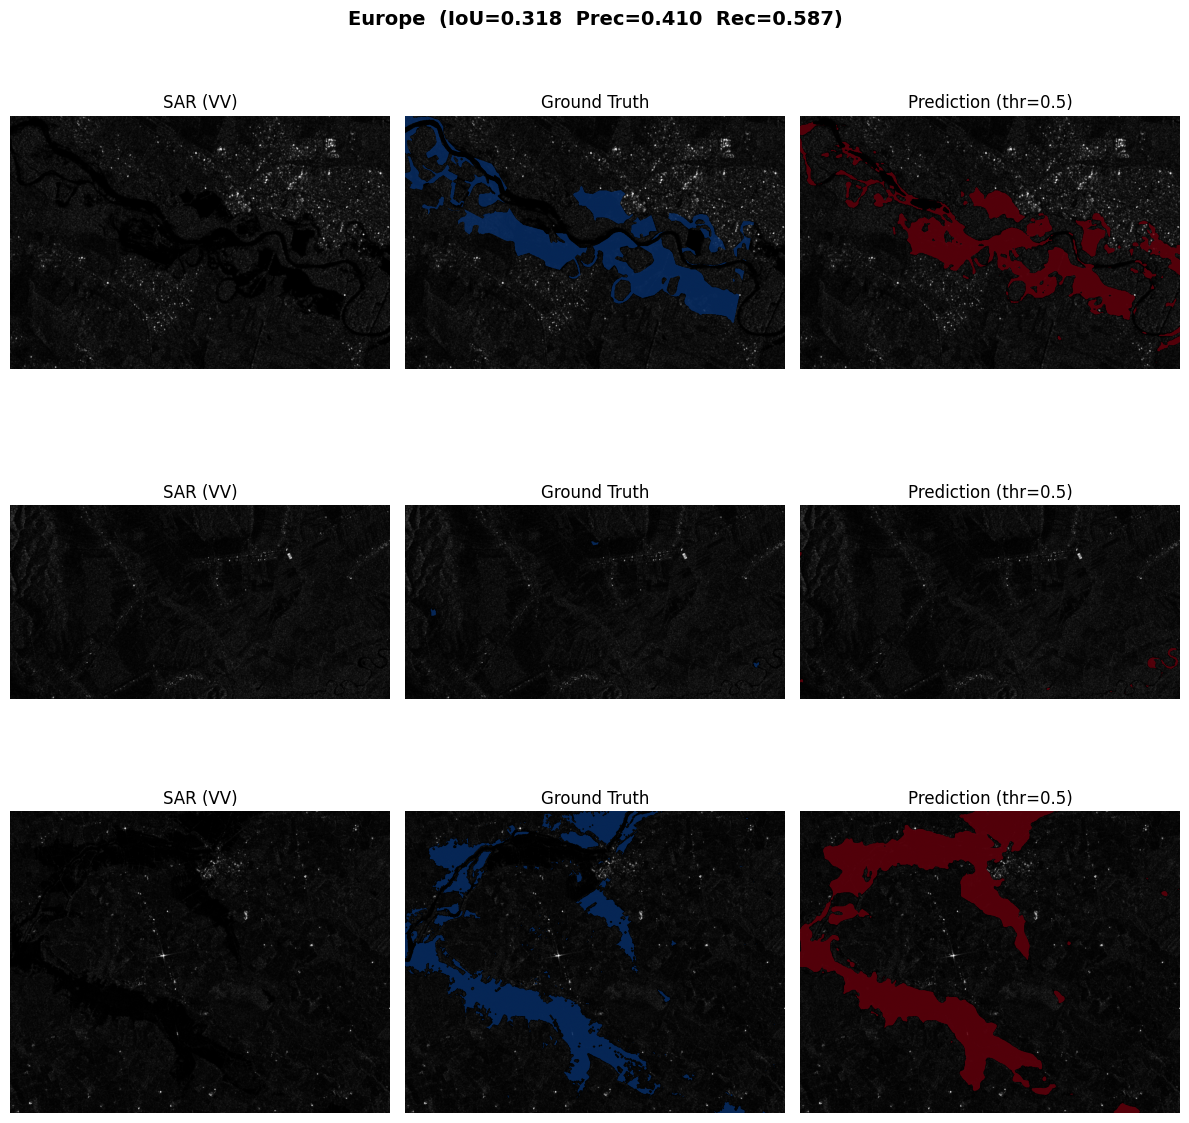

geo_vis_Europe.png


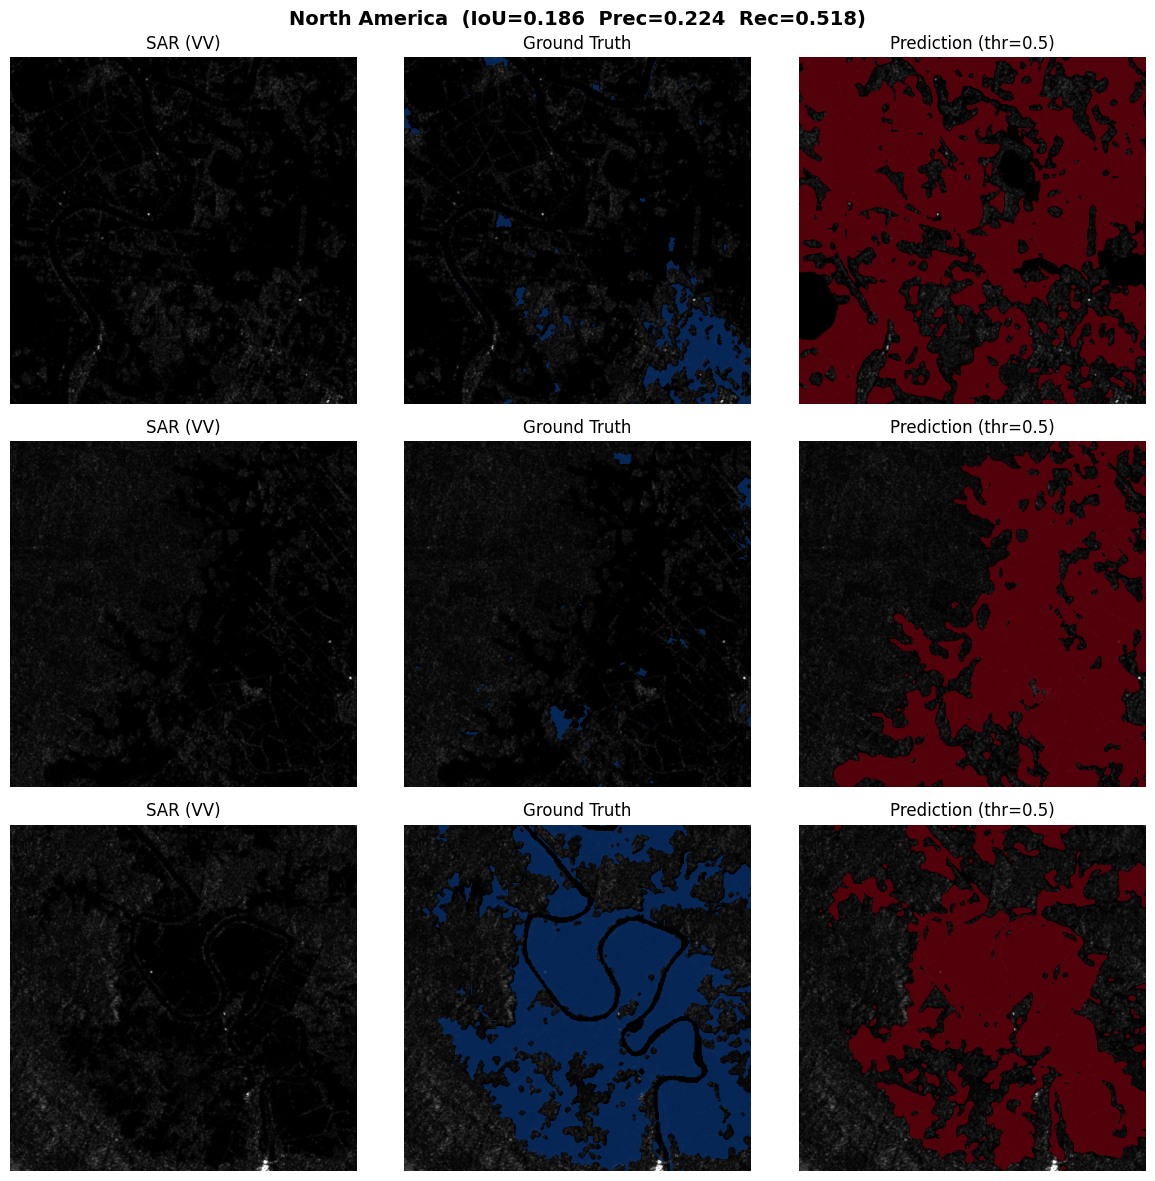

geo_vis_North_America.png


In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def visualize_geo_samples(model, dataset, indices, n_samples=3, thr=REPORT_THR, continent_name="", seed=None):
    model.eval()
    if seed is not None:
        np.random.seed(seed)
    samples = np.random.choice(indices, min(n_samples, len(indices)), replace=False)

    fig, axes = plt.subplots(n_samples, 3, figsize=(12, n_samples * 4))
    if n_samples == 1:
        axes = axes[np.newaxis, :]
    fig.suptitle(f'{continent_name}  (IoU={geo_results[continent_name]["iou"]:.3f}  '
                 f'Prec={geo_results[continent_name]["precision"]:.3f}  '
                 f'Rec={geo_results[continent_name]["recall"]:.3f})',
                 fontsize=14, fontweight='bold')

    for row, idx in enumerate(samples):
        x_original, y_original, *_ = dataset[idx]

        B, C, H, W = x_original.unsqueeze(0).shape
        pad_h = (16 - H % 16) % 16
        pad_w = (16 - W % 16) % 16

        x_padded = F.pad(x_original.unsqueeze(0), (0, pad_w, 0, pad_h), value=0)
        y_padded = F.pad(y_original.unsqueeze(0), (0, pad_w, 0, pad_h), value=255)

        with torch.no_grad():
            logits = model(x_padded.to(device))
            pred = (torch.sigmoid(logits) > thr).squeeze().cpu().numpy()
#remove padding to visualize better
        if pad_h > 0 or pad_w > 0:
            pred = pred[:H, :W]

        sar = x_original[0].numpy()
        sar_vis = np.clip((sar - sar.min()) / (sar.max() - sar.min() + 1e-8), 0, 1)

        pred_vis = pred.astype(float)
        pred_vis[pred_vis == 0] = np.nan
        pred_vis[y_original.numpy() == 255] = np.nan

        gt = y_original.numpy().astype(float)
        gt[gt == 0] = np.nan
        gt[gt == 255] = np.nan

        axes[row, 0].imshow(sar_vis, cmap='gray')
        axes[row, 0].set_title('SAR (VV)')
        axes[row, 0].axis('off')

        axes[row, 1].imshow(sar_vis, cmap='gray')
        axes[row, 1].imshow(gt, cmap='Blues', alpha=0.8, vmin=0, vmax=1)
        axes[row, 1].set_title('Ground Truth')
        axes[row, 1].axis('off')

        axes[row, 2].imshow(sar_vis, cmap='gray')
        axes[row, 2].imshow(pred_vis, cmap='Reds', alpha=0.8, vmin=0, vmax=1)
        axes[row, 2].set_title(f'Prediction (thr={thr})')
        axes[row, 2].axis('off')

    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/geo_vis_{continent_name.replace(" ", "_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'geo_vis_{continent_name.replace(" ", "_")}.png')

for continent in ['Africa', 'Europe', 'North America']:
    if continent in geo_results and continent in continent_indices:
        visualize_geo_samples(
            best_model, dm.test_ds,
            continent_indices[continent],
            continent_name=continent,
            n_samples=3,
            seed=40
        )

In [22]:
import json
from pathlib import Path
from collections import Counter
# thats the code for the non europe testing json creation
with open(ACTIVATIONS) as f:
    act = json.load(f)
print('Subsets:', Counter(v['subset'] for v in act.values()))
print('Train-Kontinente:', Counter(
    EMSR_TO_CONTINENT.get(k, 'Unknown')
    for k, v in act.items() if v['subset'] == 'train'
))
print('Val-Kontinente:', Counter(
    EMSR_TO_CONTINENT.get(k, 'Unknown')
    for k, v in act.items() if v['subset'] == 'val'
))
print('Test-Kontinente:', Counter(
    EMSR_TO_CONTINENT.get(k, 'Unknown')
    for k, v in act.items() if v['subset'] == 'test'
))

#test on all non europe
changed = 0
for emsr_id, info in act.items():
    continent = EMSR_TO_CONTINENT.get(emsr_id, 'Unknown')
    if continent != 'Europe':
        if info['subset'] != 'test':
            print(f'  {emsr_id}: {info["subset"]} → test  ({continent}, {info.get("country")})')
            act[emsr_id]['subset'] = 'test'
            changed += 1

print('Subsets:', Counter(v['subset'] for v in act.values()))
print('Test-Kontinente:', Counter(
    EMSR_TO_CONTINENT.get(k, 'Unknown')
    for k, v in act.items() if v['subset'] == 'test'
))


out_path = '/content/drive/MyDrive/activations_europe_only.json'
with open(out_path, 'w') as f:
    json.dump(act, f, indent=2)


Subsets: Counter({'train': 54, 'test': 34, 'val': 7})
Train-Kontinente: Counter({'Europe': 41, 'Africa': 5, 'Asia': 3, 'Unknown': 2, 'North America': 1, 'South America': 1, 'Oceania': 1})
Val-Kontinente: Counter({'Europe': 6, 'Oceania': 1})
Test-Kontinente: Counter({'Europe': 27, 'North America': 3, 'Africa': 1, 'Oceania': 1, 'South America': 1, 'Asia': 1})
  EMSR446: train → test  (Africa, Uganda)
  EMSR314: train → test  (Africa, Nigeria)
  EMSR479: train → test  (North America, Mexico)
  EMSR199: train → test  (South America, Peru)
  EMSR438: train → test  (Africa, Uganda)
  EMSR450: train → test  (Asia, Vietnam)
  EMSR410: train → test  (Africa, Djibouti)
  EMSR399: train → test  (Asia, Vietnam)
  EMSR342: val → test  (Oceania, Australia)
  EMSR184: train → test  (Oceania, Australia)
  EMSR319: train → test  (Unknown, Tunisia)
  EMSR424: train → test  (Africa, Madagascar)
  EMSR507: train → test  (Asia, Timor-Leste)
  EMSR419: train → test  (Unknown, Iran)
Subsets: Counter({'test':

In [23]:
#test if val test is without europe
print('Train non-Europe Events:')
for emsr_id, info in act.items():
    if info['subset'] == 'train':
        continent = EMSR_TO_CONTINENT.get(emsr_id, 'Unknown')
        if continent != 'Europe':
            print(f'  {emsr_id}: {info.get("country")} ({continent})')

print('\nVal non-Europe Events:')
for emsr_id, info in act.items():
    if info['subset'] == 'val':
        continent = EMSR_TO_CONTINENT.get(emsr_id, 'Unknown')
        if continent != 'Europe':
            print(f'  {emsr_id}: {info.get("country")} ({continent})')

Train non-Europe Events:

Val non-Europe Events:
